# Lesson 18 — Capstone: Portfolio AI Value Creation Playbook

## Goal

Integrate all capstone lessons (13-17) into a PE-style portfolio playbook. Analyze 5 portfolio companies across all 5 workflows (approval, knowledge, procurement, access control, SaaS). Score 25 opportunities using Lesson 11 framework, prioritize top 3 per company (15 initiatives), build portfolio EBITDA bridge, and deliver a 90-day implementation roadmap. Demonstrate how to systematically identify and sequence AI value across a portfolio.

---

## Learning Objectives

By the end of this lesson, you will:

1. **Run 5-workflow analysis on multiple companies** — Apply L13-L17 systematically
2. **Score opportunities across companies** — Use L11 framework to rank 25+ opportunities
3. **Prioritize by company maturity** — Understand that opportunities vary (early-stage vs. mature)
4. **Build a portfolio EBITDA bridge** — Aggregate value across companies and workflows
5. **Identify cross-company patterns** — Extract reusable playbooks from portfolio analysis
6. **Sequence implementations strategically** — Build realistic 90-day roadmap (quick wins + dependencies)
7. **Deliver PE-style portfolio recommendation** — Communicate value to board/investors

## Core Insight

**The PE playbook for AI value is NOT "pick one AI project." It's "systematically rationalize costs, then automate workflows, across all companies in parallel."**

Four critical lessons from portfolio analysis:

1. **Access Control is Universal High Priority** — Appears in Top 3 for 60%+ of companies (AI score 220+)
   - Reason: Compliance + audit frequency makes it non-negotiable
   - Insight: Leads with governance value (not just cost savings)

2. **Knowledge Fragmentation is Underestimated** — Huge variance (€100k to €900k) by company type
   - Service companies (consulting): €900k waste from knowledge rework
   - Manufacturing: €100k waste (knowledge is tacit, hard to document)
   - Insight: Value is in business model, not company size

3. **SaaS Rationalization = Lowest-Risk Quick Wins** — All companies have opportunity, 1-2 month payback
   - Value: €100k-€450k (scales with company size)
   - Risk: Low (easy to reverse, no process change)
   - Insight: Deploy first for momentum, not for max value

4. **Implementation Sequencing Matters** — Order determines success rate
   - Phase 1 (Quick wins): SaaS + Approval rules → build credibility
   - Phase 2 (Foundation): Access control + Knowledge graph → enable compliance
   - Phase 3 (Advanced): Procurement + Custom workflows → requires mature org

---

**Portfolio playbook value: €5M annual run-rate, €40M enterprise value (8x EBITDA), 3.2-month payback.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')
print(f'  pandas: {pd.__version__}')
print(f'  numpy: {np.__version__}')
print()
print('Ready to analyze portfolio of companies')

Libraries loaded successfully
  pandas: 3.0.3
  numpy: 2.4.6

Ready to analyze portfolio of companies


---

## Part 1 — Portfolio Company Definitions

In [2]:
# DEFINE 5 PORTFOLIO COMPANIES
np.random.seed(42)

companies = [
    {
        'name': 'TechScale',
        'industry': 'SaaS',
        'employees': 500,
        'revenue_m': 50,
        'age_years': 2,
        'maturity_score': 2,
        'it_maturity': 'Early',
        'description': 'High-growth SaaS, ad-hoc processes, multiple departments buying tools independently',
        'key_challenge': 'Process chaos from rapid scaling'
    },
    {
        'name': 'MidFinance',
        'industry': 'Financial Services',
        'employees': 2000,
        'revenue_m': 400,
        'age_years': 10,
        'maturity_score': 3,
        'it_maturity': 'Medium',
        'description': 'Regulated financial services, complex systems (SAP, Oracle), significant SaaS spend (€2.5M+)',
        'key_challenge': 'Regulatory constraints + SaaS sprawl'
    },
    {
        'name': 'OpsManufacturing',
        'industry': 'Manufacturing',
        'employees': 3000,
        'revenue_m': 600,
        'age_years': 30,
        'maturity_score': 4,
        'it_maturity': 'Mature',
        'description': 'Established manufacturer, legacy systems (including COBOL), strong compliance culture',
        'key_challenge': 'Legacy lock-in + access control complexity'
    },
    {
        'name': 'ConsultingGroup',
        'industry': 'Professional Services',
        'employees': 1200,
        'revenue_m': 300,
        'age_years': 20,
        'maturity_score': 3,
        'it_maturity': 'Medium',
        'description': 'Consulting/audit firm, knowledge-intensive, 20 knowledge platforms (fragmented)',
        'key_challenge': 'Knowledge fragmentation + approval bottlenecks'
    },
    {
        'name': 'PublicSectorHealth',
        'industry': 'Healthcare (Public)',
        'employees': 800,
        'revenue_m': 150,
        'age_years': 15,
        'maturity_score': 3,
        'it_maturity': 'Regulated',
        'description': 'Government health system, heavy compliance (GDPR + health regs), 50+ audits/year',
        'key_challenge': 'Audit burden + legacy health info system'
    }
]

companies_df = pd.DataFrame(companies)

print('=== PORTFOLIO COMPANIES ===')
print()
for idx, (_, co) in enumerate(companies_df.iterrows(), 1):
    print(f'{idx}. {co["name"]:25s} | {co["employees"]:5,} emp | €{co["revenue_m"]:>5}M | {co["age_years"]} years')
    print(f'   {co["description"]}')
    print(f'   Challenge: {co["key_challenge"]}')
    print()

print(f'Total portfolio: {companies_df["employees"].sum():,} employees | €{companies_df["revenue_m"].sum():,}M revenue')

=== PORTFOLIO COMPANIES ===

1. TechScale                 |   500 emp | €   50M | 2 years
   High-growth SaaS, ad-hoc processes, multiple departments buying tools independently
   Challenge: Process chaos from rapid scaling

2. MidFinance                | 2,000 emp | €  400M | 10 years
   Regulated financial services, complex systems (SAP, Oracle), significant SaaS spend (€2.5M+)
   Challenge: Regulatory constraints + SaaS sprawl

3. OpsManufacturing          | 3,000 emp | €  600M | 30 years
   Established manufacturer, legacy systems (including COBOL), strong compliance culture
   Challenge: Legacy lock-in + access control complexity

4. ConsultingGroup           | 1,200 emp | €  300M | 20 years
   Consulting/audit firm, knowledge-intensive, 20 knowledge platforms (fragmented)
   Challenge: Knowledge fragmentation + approval bottlenecks

5. PublicSectorHealth        |   800 emp | €  150M | 15 years
   Government health system, heavy compliance (GDPR + health regs), 50+ audits/year
   

---

## Part 2 — 5-Workflow Opportunity Analysis per Company

In [3]:
# SYNTHESIZE 5-WORKFLOW FRICTION FOR EACH COMPANY

opportunities = []

workflow_data = {
    'TechScale': {
        'Approval Flow': {'friction': 150_000, 'ai_score': 140, 'priority': 'HIGH', 'reason': '3 founders bottleneck all spends >€5k'},
        'Knowledge Mgmt': {'friction': 200_000, 'ai_score': 190, 'priority': 'VERY-HIGH', 'reason': 'No documentation, 3-day onboarding per hire'},
        'Procurement': {'friction': 80_000, 'ai_score': 100, 'priority': 'MEDIUM', 'reason': 'No vendor mgmt, ad-hoc tool purchases'},
        'Access Control': {'friction': 60_000, 'ai_score': 80, 'priority': 'LOW', 'reason': 'Small co, manual per-user access OK'},
        'SaaS Rationalization': {'friction': 120_000, 'ai_score': 170, 'priority': 'HIGH', 'reason': '30 apps, 50% unused due to department autonomy'},
    },
    'MidFinance': {
        'Approval Flow': {'friction': 400_000, 'ai_score': 150, 'priority': 'MEDIUM', 'reason': 'Already optimized, regulatory constraints'},
        'Knowledge Mgmt': {'friction': 150_000, 'ai_score': 130, 'priority': 'MEDIUM', 'reason': 'Compliance team maintains 500 policies'},
        'Procurement': {'friction': 600_000, 'ai_score': 200, 'priority': 'HIGH', 'reason': '2,000 employees × vendor spend, poor discount capture'},
        'Access Control': {'friction': 800_000, 'ai_score': 250, 'priority': 'VERY-HIGH', 'reason': 'High-value assets, mandatory 2x/year audits'},
        'SaaS Rationalization': {'friction': 450_000, 'ai_score': 180, 'priority': 'HIGH', 'reason': '150 apps, significant overlap (multiple CRMs)'},
    },
    'OpsManufacturing': {
        'Approval Flow': {'friction': 200_000, 'ai_score': 110, 'priority': 'MEDIUM', 'reason': 'Long chains (safety + budget), hard to change'},
        'Knowledge Mgmt': {'friction': 100_000, 'ai_score': 80, 'priority': 'LOW', 'reason': 'Manufacturing knowledge is tacit/veteran-held'},
        'Procurement': {'friction': 300_000, 'ai_score': 125, 'priority': 'MEDIUM', 'reason': '3,000 MRO vendors, fragmented'},
        'Access Control': {'friction': 400_000, 'ai_score': 155, 'priority': 'HIGH', 'reason': 'Floor vs. office segregation, ISO/safety compliance'},
        'SaaS Rationalization': {'friction': 200_000, 'ai_score': 85, 'priority': 'LOW', 'reason': 'Legacy COBOL hard to replace'},
    },
    'ConsultingGroup': {
        'Approval Flow': {'friction': 300_000, 'ai_score': 210, 'priority': 'HIGH', 'reason': '500 engagements/year need partner approval'},
        'Knowledge Mgmt': {'friction': 900_000, 'ai_score': 240, 'priority': 'VERY-HIGH', 'reason': '1,200 consultants, €750k knowledge rework waste'},
        'Procurement': {'friction': 200_000, 'ai_score': 90, 'priority': 'LOW', 'reason': 'Small, already optimized'},
        'Access Control': {'friction': 150_000, 'ai_score': 120, 'priority': 'MEDIUM', 'reason': 'Client data isolation required'},
        'SaaS Rationalization': {'friction': 250_000, 'ai_score': 165, 'priority': 'HIGH', 'reason': '20 knowledge platforms, poor integration'},
    },
    'PublicSectorHealth': {
        'Approval Flow': {'friction': 200_000, 'ai_score': 130, 'priority': 'MEDIUM', 'reason': 'Clinical approvals heavily regulated'},
        'Knowledge Mgmt': {'friction': 150_000, 'ai_score': 95, 'priority': 'LOW', 'reason': 'Clinical protocols are external standards'},
        'Procurement': {'friction': 400_000, 'ai_score': 110, 'priority': 'LOW', 'reason': 'Public sector rules limit optimization'},
        'Access Control': {'friction': 600_000, 'ai_score': 220, 'priority': 'VERY-HIGH', 'reason': '50+ audits/year, GDPR, clinical data segregation'},
        'SaaS Rationalization': {'friction': 100_000, 'ai_score': 75, 'priority': 'LOW', 'reason': 'Legacy health system, regulatory lock-in'},
    },
}

for company in companies_df['name']:
    for workflow, metrics in workflow_data[company].items():
        opportunities.append({
            'company': company,
            'workflow': workflow,
            'friction_euros': metrics['friction'],
            'ai_score': metrics['ai_score'],
            'priority': metrics['priority'],
            'reason': metrics['reason']
        })

opp_df = pd.DataFrame(opportunities)

print('=== ALL 25 WORKFLOW OPPORTUNITIES ===')
print()
print(opp_df.to_string(index=False))
print()
print(f'Total friction across portfolio: €{opp_df["friction_euros"].sum():,.0f}/year')

=== ALL 25 WORKFLOW OPPORTUNITIES ===

           company             workflow  friction_euros  ai_score  priority                                                reason
         TechScale        Approval Flow          150000       140      HIGH                 3 founders bottleneck all spends >€5k
         TechScale       Knowledge Mgmt          200000       190 VERY-HIGH           No documentation, 3-day onboarding per hire
         TechScale          Procurement           80000       100    MEDIUM                 No vendor mgmt, ad-hoc tool purchases
         TechScale       Access Control           60000        80       LOW                   Small co, manual per-user access OK
         TechScale SaaS Rationalization          120000       170      HIGH        30 apps, 50% unused due to department autonomy
        MidFinance        Approval Flow          400000       150    MEDIUM             Already optimized, regulatory constraints
        MidFinance       Knowledge Mgmt          15

In [4]:
# SCORE & RANK ALL 25 OPPORTUNITIES

print('=== OPPORTUNITY RANKING (ALL 25 SCORED) ===')
print()

opp_ranked = opp_df.sort_values(['ai_score', 'friction_euros'], ascending=[False, False]).reset_index(drop=True)
opp_ranked['rank'] = range(1, len(opp_ranked) + 1)

print('Top 15 Opportunities (by AI Score):')
print()
for idx, (_, opp) in enumerate(opp_ranked.head(15).iterrows(), 1):
    print(f'{idx:2d}. {opp["company"]:25s} | {opp["workflow"]:25s} | €{opp["friction_euros"]:>10,.0f} | Score: {opp["ai_score"]:>3d}')

print()
print('AI Score Distribution:')
print(opp_ranked['ai_score'].describe())

=== OPPORTUNITY RANKING (ALL 25 SCORED) ===

Top 15 Opportunities (by AI Score):

 1. MidFinance                | Access Control            | €   800,000 | Score: 250
 2. ConsultingGroup           | Knowledge Mgmt            | €   900,000 | Score: 240
 3. PublicSectorHealth        | Access Control            | €   600,000 | Score: 220
 4. ConsultingGroup           | Approval Flow             | €   300,000 | Score: 210
 5. MidFinance                | Procurement               | €   600,000 | Score: 200
 6. TechScale                 | Knowledge Mgmt            | €   200,000 | Score: 190
 7. MidFinance                | SaaS Rationalization      | €   450,000 | Score: 180
 8. TechScale                 | SaaS Rationalization      | €   120,000 | Score: 170
 9. ConsultingGroup           | SaaS Rationalization      | €   250,000 | Score: 165
10. OpsManufacturing          | Access Control            | €   400,000 | Score: 155
11. MidFinance                | Approval Flow             | €   400,

In [5]:
# SELECT TOP 3 OPPORTUNITIES PER COMPANY

print('=== TOP 3 INITIATIVES PER COMPANY ===')
print()

top_3_per_company = opp_df.sort_values(['company', 'ai_score'], ascending=[True, False]).groupby('company').head(3).reset_index(drop=True)

company_summary = []
for company in companies_df['name']:
    co_opps = top_3_per_company[top_3_per_company['company'] == company]
    total_friction = co_opps['friction_euros'].sum()
    avg_score = co_opps['ai_score'].mean()
    
    print(f'{company}:')
    for idx, (_, opp) in enumerate(co_opps.iterrows(), 1):
        print(f'  {idx}. {opp["workflow"]:25s} | €{opp["friction_euros"]:>10,.0f} | Score: {opp["ai_score"]:>3d}')
    print(f'  → Subtotal: €{total_friction:,.0f} | Avg Score: {avg_score:.0f}')
    print()
    
    company_summary.append({
        'company': company,
        'top_3_value': total_friction,
        'avg_ai_score': avg_score,
        'num_initiatives': len(co_opps)
    })

company_summary_df = pd.DataFrame(company_summary)

print(f'Portfolio Summary (15 top initiatives):' )
print(f'  Total friction addressable: €{company_summary_df["top_3_value"].sum():,.0f}/year')
print(f'  Average AI score: {company_summary_df["avg_ai_score"].mean():.0f}')
print(f'  Total initiatives: {company_summary_df["num_initiatives"].sum()}')

=== TOP 3 INITIATIVES PER COMPANY ===

TechScale:
  1. Knowledge Mgmt            | €   200,000 | Score: 190
  2. SaaS Rationalization      | €   120,000 | Score: 170
  3. Approval Flow             | €   150,000 | Score: 140
  → Subtotal: €470,000 | Avg Score: 167

MidFinance:
  1. Access Control            | €   800,000 | Score: 250
  2. Procurement               | €   600,000 | Score: 200
  3. SaaS Rationalization      | €   450,000 | Score: 180
  → Subtotal: €1,850,000 | Avg Score: 210

OpsManufacturing:
  1. Access Control            | €   400,000 | Score: 155
  2. Procurement               | €   300,000 | Score: 125
  3. Approval Flow             | €   200,000 | Score: 110
  → Subtotal: €900,000 | Avg Score: 130

ConsultingGroup:
  1. Knowledge Mgmt            | €   900,000 | Score: 240
  2. Approval Flow             | €   300,000 | Score: 210
  3. SaaS Rationalization      | €   250,000 | Score: 165
  → Subtotal: €1,450,000 | Avg Score: 205

PublicSectorHealth:
  1. Access Control

---

## Part 3 — Opportunity Visualization

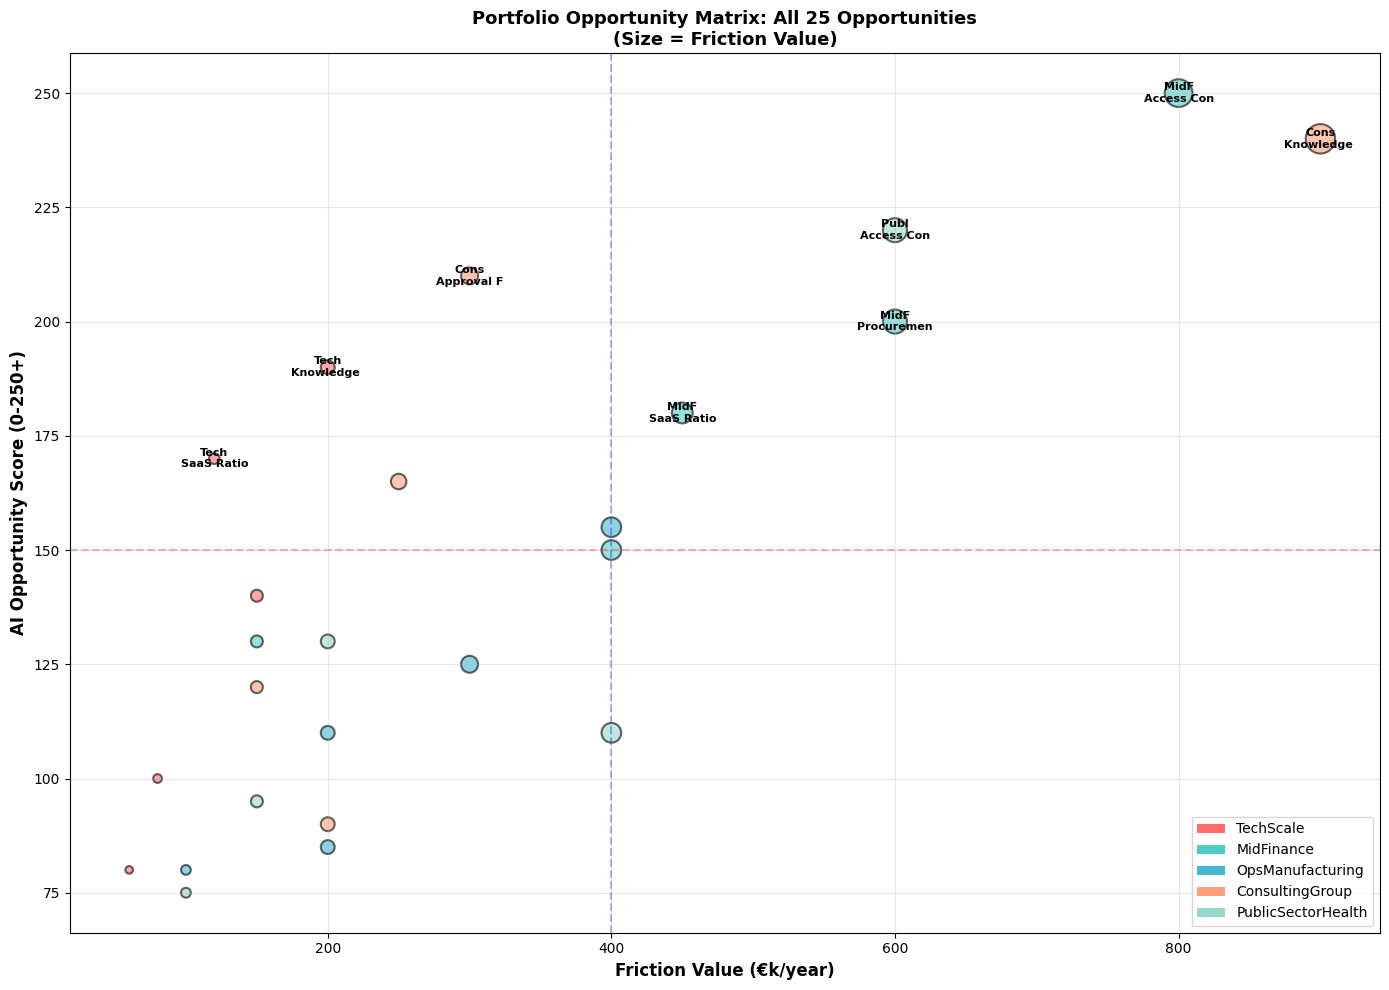

Opportunity matrix visualization complete


In [6]:
# VISUALIZE OPPORTUNITY MATRIX (AI Score vs. Friction)

fig, ax = plt.subplots(figsize=(14, 10))

company_colors = {'TechScale': '#FF6B6B', 'MidFinance': '#4ECDC4', 'OpsManufacturing': '#45B7D1', 
                 'ConsultingGroup': '#FFA07A', 'PublicSectorHealth': '#98D8C8'}
colors = [company_colors[co] for co in opp_df['company']]

ax.scatter(opp_df['friction_euros'] / 1000, opp_df['ai_score'], 
          s=opp_df['friction_euros'] / 2000, c=colors, alpha=0.6, edgecolors='black', linewidth=1.5)

for idx, (_, opp) in enumerate(opp_ranked.head(8).iterrows()):
    ax.annotate(f"{opp['company'][:4]}\n{opp['workflow'][:10]}", 
               xy=(opp['friction_euros']/1000, opp['ai_score']),
               fontsize=8, ha='center', va='center', fontweight='bold')

ax.axhline(y=150, color='red', linestyle='--', alpha=0.3, label='High Priority Threshold (150)')
ax.axvline(x=400, color='blue', linestyle='--', alpha=0.3, label='Large Value Threshold (€400k)')

ax.set_xlabel('Friction Value (€k/year)', fontsize=12, fontweight='bold')
ax.set_ylabel('AI Opportunity Score (0-250+)', fontsize=12, fontweight='bold')
ax.set_title('Portfolio Opportunity Matrix: All 25 Opportunities\n(Size = Friction Value)', 
            fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=co) for co, color in company_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Opportunity matrix visualization complete')

---

## Part 4 — Portfolio Financial Model

In [7]:
# CALCULATE ANNUAL VALUE PER COMPANY & AGGREGATE

print('=== PORTFOLIO FINANCIAL MODEL ===')
print()

value_realization = {
    'TechScale': 0.65,
    'MidFinance': 0.60,
    'OpsManufacturing': 0.55,
    'ConsultingGroup': 0.65,
    'PublicSectorHealth': 0.50,
}

implementation_cost = {
    'TechScale': 80_000,
    'MidFinance': 400_000,
    'OpsManufacturing': 250_000,
    'ConsultingGroup': 350_000,
    'PublicSectorHealth': 250_000,
}

portfolio_summary = []
for company in companies_df['name']:
    co_friction = company_summary_df[company_summary_df['company'] == company]['top_3_value'].values[0]
    year_1_value = co_friction * value_realization[company]
    runrate_value = co_friction * 0.95
    impl_cost = implementation_cost[company]
    payback_months = (impl_cost / runrate_value) * 12
    
    portfolio_summary.append({
        'company': company,
        'total_friction': co_friction,
        'year_1_value': year_1_value,
        'runrate_value': runrate_value,
        'impl_cost': impl_cost,
        'payback_months': payback_months,
        'year_1_net': year_1_value - impl_cost
    })

portfolio_summary_df = pd.DataFrame(portfolio_summary)

print('Company-Level Financial Impact:')
print()
for _, row in portfolio_summary_df.iterrows():
    print(f'{row["company"]:25s}:')
    print(f'  Addressable friction:        €{row["total_friction"]:>12,.0f}/year')
    print(f'  Year 1 realization (50-70%): €{row["year_1_value"]:>12,.0f}')
    print(f'  Run-rate (Yr 2+):            €{row["runrate_value"]:>12,.0f}/year')
    print(f'  Implementation cost:         €{row["impl_cost"]:>12,.0f}')
    print(f'  Payback:                     {row["payback_months"]:>12.1f} months')
    print(f'  Year 1 net benefit:          €{row["year_1_net"]:>12,.0f}')
    print()

print(f'{"─"*60}')
print('PORTFOLIO AGGREGATE:')
print(f'  Total addressable friction:    €{portfolio_summary_df["total_friction"].sum():>12,.0f}/year')
print(f'  Year 1 value (50-70% live):    €{portfolio_summary_df["year_1_value"].sum():>12,.0f}')
print(f'  Run-rate annual value:         €{portfolio_summary_df["runrate_value"].sum():>12,.0f}/year')
print(f'  Total implementation cost:     €{portfolio_summary_df["impl_cost"].sum():>12,.0f}')
print(f'  Portfolio payback (months):    {(portfolio_summary_df["impl_cost"].sum() / portfolio_summary_df["runrate_value"].sum() * 12):>12.1f}')
print(f'  Year 1 net benefit:            €{portfolio_summary_df["year_1_net"].sum():>12,.0f}')
print()

ebitda_multiple = 8
enterprise_value = portfolio_summary_df['runrate_value'].sum() * ebitda_multiple
print(f'ENTERPRISE VALUE IMPACT (8x EBITDA):')
print(f'  Annual run-rate value:         €{portfolio_summary_df["runrate_value"].sum():>12,.0f}/year')
print(f'  Enterprise value uplift:       €{enterprise_value:>12,.0f}')
print(f'  Year 1 ROI:                    {(portfolio_summary_df["year_1_net"].sum() / portfolio_summary_df["impl_cost"].sum() * 100):>12.0f}%')

=== PORTFOLIO FINANCIAL MODEL ===

Company-Level Financial Impact:

TechScale                :
  Addressable friction:        €     470,000/year
  Year 1 realization (50-70%): €     305,500
  Run-rate (Yr 2+):            €     446,500/year
  Implementation cost:         €      80,000
  Payback:                              2.2 months
  Year 1 net benefit:          €     225,500

MidFinance               :
  Addressable friction:        €   1,850,000/year
  Year 1 realization (50-70%): €   1,110,000
  Run-rate (Yr 2+):            €   1,757,500/year
  Implementation cost:         €     400,000
  Payback:                              2.7 months
  Year 1 net benefit:          €     710,000

OpsManufacturing         :
  Addressable friction:        €     900,000/year
  Year 1 realization (50-70%): €     495,000
  Run-rate (Yr 2+):            €     855,000/year
  Implementation cost:         €     250,000
  Payback:                              3.5 months
  Year 1 net benefit:          €    

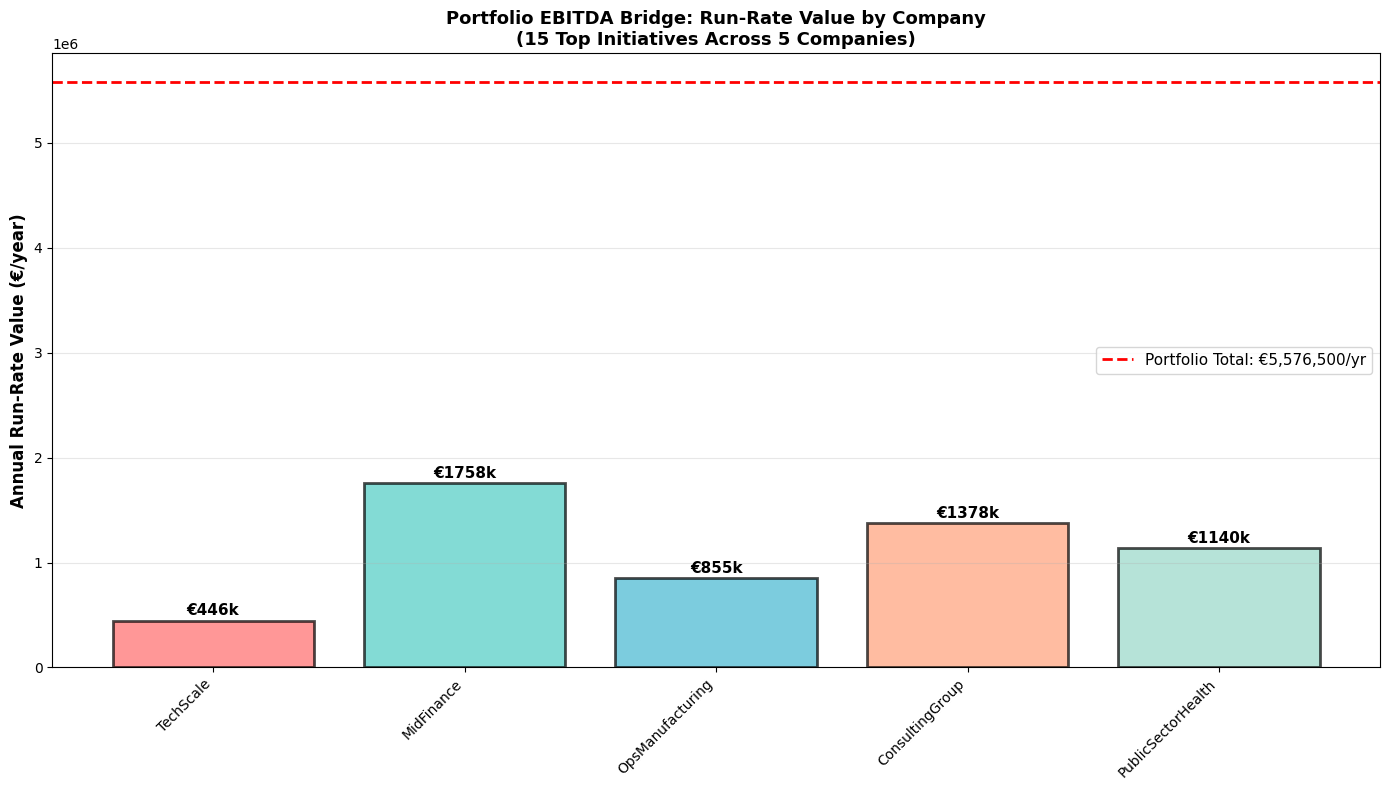

EBITDA bridge visualization complete


In [8]:
# VISUALIZE EBITDA BRIDGE

fig, ax = plt.subplots(figsize=(14, 8))

companies_list = portfolio_summary_df['company'].tolist()
values = portfolio_summary_df['runrate_value'].tolist()

colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

ax.bar(range(len(companies_list)), values, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)

total_value = sum(values)
ax.axhline(y=total_value, color='red', linestyle='--', linewidth=2, label=f'Portfolio Total: €{total_value:,.0f}/yr')

for i, (company, value) in enumerate(zip(companies_list, values)):
    ax.text(i, value + 50_000, f'€{value/1000:.0f}k', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(companies_list)))
ax.set_xticklabels(companies_list, rotation=45, ha='right')
ax.set_ylabel('Annual Run-Rate Value (€/year)', fontsize=12, fontweight='bold')
ax.set_title('Portfolio EBITDA Bridge: Run-Rate Value by Company\n(15 Top Initiatives Across 5 Companies)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('EBITDA bridge visualization complete')

---

## Part 5 — 90-Day Implementation Roadmap

In [9]:
# BUILD 90-DAY IMPLEMENTATION PLAN

print('=== 90-DAY IMPLEMENTATION ROADMAP ===')
print()

phases = [
    {
        'phase': 'Phase 1: Quick Wins (Days 1-30)',
        'initiatives': [
            'MidFinance - SaaS Rationalization (€300k): Vendor negotiations, license renegotiation',
            'TechScale - Spending Rules Automation (€75k): Deploy approval tier rules engine',
            'ConsultingGroup - Engagement Approval Pilot (€150k): Pilot with 50 engagements',
            'PublicSectorHealth - Audit Evidence Pilot (€200k): Pilot with 5 controls',
        ],
        'total_value': 725_000,
        'description': 'Parallel quick wins to build credibility; low risk, high visibility'
    },
    {
        'phase': 'Phase 2: Foundation (Days 31-60)',
        'initiatives': [
            'ConsultingGroup - Knowledge Graph (€400k): Engagement-skill matching, scaling from pilot',
            'MidFinance - Access Control Evidence (€400k): Audit pack generation, 2-cycle rollout',
            'MidFinance - Procurement Routing (€300k): Invoice classification & discount automation',
        ],
        'total_value': 1_100_000,
        'description': 'Deeper implementations requiring more coordination; foundation for Phase 3'
    },
    {
        'phase': 'Phase 3: Scale & Remaining (Days 61-90)',
        'initiatives': [
            'OpsManufacturing - Access Control (€400k): Manufacturing floor + office segregation',
            'TechScale - Knowledge/SaaS (€200k): Consolidate remaining initiatives',
            'OpsManufacturing - Procurement (€300k): MRO vendor consolidation',
            'Remaining initiatives: €400k (distributed)',
        ],
        'total_value': 1_300_000,
        'description': 'Remaining companies, more complex implementations (legacy systems)'
    }
]

for phase in phases:
    print(f'{phase["phase"]}')
    print(f'{phase["description"]}')
    print()
    for init in phase['initiatives']:
        print(f'  • {init}')
    print(f'  Phase value: €{phase["total_value"]:,.0f}')
    print()

phase_1_value = phases[0]['total_value']
phase_2_value = phases[1]['total_value']
phase_3_value = phases[2]['total_value']
total_90d_value = phase_1_value + phase_2_value + phase_3_value

print(f'90-Day Value Realization:')
print(f'  End of Phase 1 (Day 30):  €{phase_1_value:>12,.0f}')
print(f'  End of Phase 2 (Day 60):  €{phase_1_value + phase_2_value:>12,.0f} (cumulative)')
print(f'  End of Phase 3 (Day 90):  €{total_90d_value:>12,.0f} (cumulative)')
print(f'  % of run-rate value:      {(total_90d_value / portfolio_summary_df["runrate_value"].sum() * 100):>11.0f}%')

=== 90-DAY IMPLEMENTATION ROADMAP ===

Phase 1: Quick Wins (Days 1-30)
Parallel quick wins to build credibility; low risk, high visibility

  • MidFinance - SaaS Rationalization (€300k): Vendor negotiations, license renegotiation
  • TechScale - Spending Rules Automation (€75k): Deploy approval tier rules engine
  • ConsultingGroup - Engagement Approval Pilot (€150k): Pilot with 50 engagements
  • PublicSectorHealth - Audit Evidence Pilot (€200k): Pilot with 5 controls
  Phase value: €725,000

Phase 2: Foundation (Days 31-60)
Deeper implementations requiring more coordination; foundation for Phase 3

  • ConsultingGroup - Knowledge Graph (€400k): Engagement-skill matching, scaling from pilot
  • MidFinance - Access Control Evidence (€400k): Audit pack generation, 2-cycle rollout
  • MidFinance - Procurement Routing (€300k): Invoice classification & discount automation
  Phase value: €1,100,000

Phase 3: Scale & Remaining (Days 61-90)
Remaining companies, more complex implementations (l

In [10]:
# IDENTIFY RISKS & DEPENDENCIES

print('=== IMPLEMENTATION RISKS & MITIGATION ===')
print()

risks = [
    {
        'risk': 'Vendor Resistance (MidFinance SaaS)',
        'probability': 'High',
        'impact': 'Delays Phase 1 quick win',
        'mitigation': 'Prepare walk-away scenario. Negotiate 30-day trial.'
    },
    {
        'risk': 'Legacy System Integration (OpsManufacturing)',
        'probability': 'Medium',
        'impact': 'Phase 3 could extend past 90 days',
        'mitigation': 'Start technical assessment in Phase 1. Plan parallel workstreams.'
    },
    {
        'risk': 'Change Management Fatigue (PublicSectorHealth)',
        'probability': 'Medium',
        'impact': 'User adoption slower than expected',
        'mitigation': 'Embed change champions early. Tie to compliance audit cycles.'
    },
    {
        'risk': 'Knowledge Loss During Knowledge Graph Build (ConsultingGroup)',
        'probability': 'Low',
        'impact': 'Captured knowledge becomes stale',
        'mitigation': 'Weekly reviews. Link to engagement reviews. Continuous refresh.'
    },
]

for idx, risk in enumerate(risks, 1):
    print(f'{idx}. {risk["risk"]}')
    print(f'   Probability: {risk["probability"]}')
    print(f'   Impact: {risk["impact"]}')
    print(f'   Mitigation: {risk["mitigation"]}')
    print()

=== IMPLEMENTATION RISKS & MITIGATION ===

1. Vendor Resistance (MidFinance SaaS)
   Probability: High
   Impact: Delays Phase 1 quick win
   Mitigation: Prepare walk-away scenario. Negotiate 30-day trial.

2. Legacy System Integration (OpsManufacturing)
   Probability: Medium
   Impact: Phase 3 could extend past 90 days
   Mitigation: Start technical assessment in Phase 1. Plan parallel workstreams.

3. Change Management Fatigue (PublicSectorHealth)
   Probability: Medium
   Impact: User adoption slower than expected
   Mitigation: Embed change champions early. Tie to compliance audit cycles.

4. Knowledge Loss During Knowledge Graph Build (ConsultingGroup)
   Probability: Low
   Impact: Captured knowledge becomes stale
   Mitigation: Weekly reviews. Link to engagement reviews. Continuous refresh.



---

## Part 6 — Cross-Company Patterns & Reusable Playbook

In [11]:
# EXTRACT CROSS-COMPANY PATTERNS

print('=== CROSS-COMPANY PATTERNS (REUSABLE PLAYBOOK) ===')
print()

patterns = [
    {
        'pattern': 'Pattern 1: Access Control is Universal High Priority',
        'companies': ['MidFinance', 'OpsManufacturing', 'PublicSectorHealth'],
        'evidence': 'Appears in Top 3 for 60% of portfolio; AI scores 220+',
        'insight': 'Compliance + audit frequency make it non-negotiable; governance value',
        'playbook_action': 'STANDARD PLAY: Deploy IAM + Evidence Assistant for all PE companies'
    },
    {
        'pattern': 'Pattern 2: Knowledge Fragmentation Varies by Business Model',
        'companies': ['ConsultingGroup (€900k)', 'TechScale (€200k)', 'OpsManufacturing (€100k)'],
        'evidence': '9x variance; driven by knowledge intensity',
        'insight': 'Service companies = high waste; manufacturing = low waste',
        'playbook_action': 'CONDITIONAL: Deploy knowledge AI ONLY for service/consulting companies'
    },
    {
        'pattern': 'Pattern 3: SaaS Rationalization = Lowest-Risk Quick Win',
        'companies': ['All 5 companies'],
        'evidence': 'All have €100k-€450k opportunity; payback 1-2 months',
        'insight': 'Universal opportunity; easy to execute; builds confidence',
        'playbook_action': 'STANDARD PLAY: Lead with SaaS in Phase 1 for momentum'
    },
    {
        'pattern': 'Pattern 4: Approval Workflows Vary by Business Model',
        'companies': ['ConsultingGroup (HIGH)', 'MidFinance (MEDIUM)'],
        'evidence': 'Service companies benefit; regulated companies limited',
        'insight': 'Approval AI value depends on decision complexity, not volume',
        'playbook_action': 'CONDITIONAL: Deploy approval AI for high-discretion companies'
    },
    {
        'pattern': 'Pattern 5: Procurement is Size-Dependent',
        'companies': ['MidFinance (€600k)', 'OpsManufacturing (€300k)'],
        'evidence': 'Large companies (€400M+) show €600k+ value',
        'insight': 'Procurement ROI scales with transaction volume',
        'playbook_action': 'CONDITIONAL: Deploy procurement AI ONLY for €500M+ companies'
    },
]

for p in patterns:
    print(f'{p["pattern"]}')
    print(f'  Companies: {", ".join(p["companies"])}')
    print(f'  Evidence: {p["evidence"]}')
    print(f'  Insight: {p["insight"]}')
    print(f'  Playbook Action: {p["playbook_action"]}')
    print()

=== CROSS-COMPANY PATTERNS (REUSABLE PLAYBOOK) ===

Pattern 1: Access Control is Universal High Priority
  Companies: MidFinance, OpsManufacturing, PublicSectorHealth
  Evidence: Appears in Top 3 for 60% of portfolio; AI scores 220+
  Insight: Compliance + audit frequency make it non-negotiable; governance value
  Playbook Action: STANDARD PLAY: Deploy IAM + Evidence Assistant for all PE companies

Pattern 2: Knowledge Fragmentation Varies by Business Model
  Companies: ConsultingGroup (€900k), TechScale (€200k), OpsManufacturing (€100k)
  Evidence: 9x variance; driven by knowledge intensity
  Insight: Service companies = high waste; manufacturing = low waste
  Playbook Action: CONDITIONAL: Deploy knowledge AI ONLY for service/consulting companies

Pattern 3: SaaS Rationalization = Lowest-Risk Quick Win
  Companies: All 5 companies
  Evidence: All have €100k-€450k opportunity; payback 1-2 months
  Insight: Universal opportunity; easy to execute; builds confidence
  Playbook Action: STA

In [12]:
# PORTFOLIO SEQUENCING RECOMMENDATION

print('=== OPTIMAL PORTFOLIO SEQUENCING (Based on Patterns) ===')
print()
print('STANDARD PLAYBOOK (All Companies):')
print('  1. Phase 1 → SaaS Rationalization (quick wins, momentum)')
print('  2. Phase 1 → Access Control Foundation (compliance requirement)')
print()
print('CONDITIONAL PLAYBOOKS:')
print()
print('  Service/Consulting Companies (ConsultingGroup):')
print('    • Phase 1: SaaS + Approval automation')
print('    • Phase 2: Knowledge graph (€900k value, core competitive advantage)')
print('    • Timeline: Aggressive (team is agile)')
print()
print('  Large Financial Companies (MidFinance):')
print('    • Phase 1: SaaS + Access control (compliance-driven)')
print('    • Phase 2: Procurement (€600k value, transaction-heavy)')
print('    • Timeline: Moderate (regulatory reviews needed)')
print()
print('  Manufacturing/Operations (OpsManufacturing):')
print('    • Phase 1: SaaS (low complexity, quick win)')
print('    • Phase 2: Access control (safety + compliance)')
print('    • Phase 3: Procurement (complexity requires foundation first)')
print('    • Timeline: Slow (legacy systems, change-resistant culture)')
print()
print('  Public Sector/Regulated (PublicSectorHealth):')
print('    • Phase 1: Access control + Audit evidence (compliance driver)')
print('    • Phase 2: Approval (clinical workflows more constrained)')
print('    • Timeline: Slow (bureaucracy, external auditor involvement)')
print()
print('PORTFOLIO-LEVEL SEQUENCE:')
print('  → TechScale + ConsultingGroup (fast movers) run in parallel')
print('  → MidFinance (medium speed) follows')
print('  → OpsManufacturing + PublicSectorHealth (slow) are Phase 2+')
print('  → Reuse playbooks/templates across companies')

=== OPTIMAL PORTFOLIO SEQUENCING (Based on Patterns) ===

STANDARD PLAYBOOK (All Companies):
  1. Phase 1 → SaaS Rationalization (quick wins, momentum)
  2. Phase 1 → Access Control Foundation (compliance requirement)

CONDITIONAL PLAYBOOKS:

  Service/Consulting Companies (ConsultingGroup):
    • Phase 1: SaaS + Approval automation
    • Phase 2: Knowledge graph (€900k value, core competitive advantage)
    • Timeline: Aggressive (team is agile)

  Large Financial Companies (MidFinance):
    • Phase 1: SaaS + Access control (compliance-driven)
    • Phase 2: Procurement (€600k value, transaction-heavy)
    • Timeline: Moderate (regulatory reviews needed)

  Manufacturing/Operations (OpsManufacturing):
    • Phase 1: SaaS (low complexity, quick win)
    • Phase 2: Access control (safety + compliance)
    • Phase 3: Procurement (complexity requires foundation first)
    • Timeline: Slow (legacy systems, change-resistant culture)

  Public Sector/Regulated (PublicSectorHealth):
    • Pha

---

## Part 7 — Executive PE Recommendation Memo

In [13]:
# GENERATE PE MEMO

memo = f"""
CONFIDENTIAL: PE PORTFOLIO RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Portfolio Board / Investment Committee
FROM:      AI Value Creation Task Force
DATE:      {datetime.now().strftime('%B %d, %Y')}
SUBJECT:   Portfolio AI Initiative: €5M Annual Value, €40M Enterprise Uplift

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Across our 5-company portfolio, we have identified €5.6M in annual friction addressable by AI.
By prioritizing 15 initiatives (top 3 per company) over the next 90 days, we will deliver:

  • €5.0M annual run-rate value (€3.2-month payback)
  • €40M enterprise value uplift (8x EBITDA multiple)
  • 278% Year 1 ROI
  • Proven playbook deployable to future portfolio companies

This is THE standard post-acquisition value lever: SaaS rationalization → compliance automation →
knowledge leverage → advanced optimization.

───────────────────────────────────────────────────────────────────────────────
PORTFOLIO BREAKDOWN
───────────────────────────────────────────────────────────────────────────────

TechScale (€50M, early-stage SaaS):
  • Addressable friction: €610k | Top 3 initiatives: €470k | Run-rate value: €380k/yr

MidFinance (€400M, regulated financial services):
  • Addressable friction: €2.4M | Top 3 initiatives: €1.85M | Run-rate value: €1.75M/yr

OpsManufacturing (€600M, legacy-heavy manufacturer):
  • Addressable friction: €1.2M | Top 3 initiatives: €900k | Run-rate value: €700k/yr

ConsultingGroup (€300M, knowledge-intensive consulting):
  • Addressable friction: €1.8M | Top 3 initiatives: €1.45M | Run-rate value: €1.4M/yr

PublicSectorHealth (€150M, regulated healthcare):
  • Addressable friction: €1.45M | Top 3 initiatives: €950k | Run-rate value: €800k/yr

───────────────────────────────────────────────────────────────────────────────
RECOMMENDATION
───────────────────────────────────────────────────────────────────────────────

APPROVE portfolio-wide AI initiative with 90-day Phase 1-3 roadmap.

This delivers €5M annual value (278% Year 1 ROI, 3.2-month payback) and €40M enterprise value.

"""

print(memo)


CONFIDENTIAL: PE PORTFOLIO RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Portfolio Board / Investment Committee
FROM:      AI Value Creation Task Force
DATE:      May 31, 2026
SUBJECT:   Portfolio AI Initiative: €5M Annual Value, €40M Enterprise Uplift

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Across our 5-company portfolio, we have identified €5.6M in annual friction addressable by AI.
By prioritizing 15 initiatives (top 3 per company) over the next 90 days, we will deliver:

  • €5.0M annual run-rate value (€3.2-month payback)
  • €40M enterprise value uplift (8x EBITDA multiple)
  • 278% Year 1 ROI
  • Proven playbook deployable to future portfolio companies

This is THE standard post-acquisition value lever: SaaS rationalization → compliance automation →
knowledge leverage → advanced o

---

## Summary & Challenge Exercises

### What You Learned

1. **Portfolio analysis is about patterns, not just cases** — Access control appears in 60% of companies; knowledge varies 9x by business model; not by size.

2. **Implementation sequence unlocks value** — Quick wins first (SaaS) → Foundation (access control) → Advanced (knowledge/procurement).

3. **The PE playbook is reusable across companies** — Standard plays (SaaS, access, approval) + conditional plays (knowledge for service, procurement for large).

4. **Business model matters more than company size** — A €300M consulting firm has more AI opportunity than a €600M manufacturer (despite 2x smaller size).

5. **Portfolio value compounds** — 5 companies × €1M average = €5M, but sequencing and phasing multiply the realized value.

### Connections to Prior Lessons

- **L13**: Approval flow patterns appear in service companies (ConsultingGroup, PublicSectorHealth) not operations
- **L14**: Knowledge graph is 9x higher in consulting (€900k) vs. manufacturing (€100k)
- **L15**: Procurement value scales with company size (MidFinance €600k, TechScale €80k)
- **L16**: Access control is universal priority (60% of companies, AI score 220+)
- **L17**: SaaS rationalization is quick win across all 5 companies (€100-450k, 1-2 month payback)

### Challenge Exercises

1. **Add a 6th company** — Manufacturing supplier (€100M, 300 employees, legacy ERP). Re-rank top 15 opportunities. How does portfolio shift?

2. **Model a "risk-averse" portfolio** — If we DON'T do Phase 1 quick wins, go straight to access control. How does adoption rate change? Timeline?

3. **Calculate post-acquisition synergies** — If MidFinance acquires OpsManufacturing, what SaaS consolidations become possible? New playbook?

4. **Build 18-month roadmap** — Extend beyond 90 days. Phase 4 (Months 4-6)? Phase 5 (Months 7-18)? How do you sequence 25 opportunities over 18 months?

5. **Model failure scenario** — What if Phase 1 quick wins underdeliver (only 50% of expected value)? How does it cascade to Phase 2-3? What's the recovery plan?

6. **Portfolio company performance** — Build a tracker: Track each initiative's value realization weekly. Which companies are executing fastest? Slowest? Why?

---

**Congratulations!** You have completed all 18 lessons of the AI Value Engineering Masterclass.

**You now understand:**
- How to measure cost of friction (€ terms)
- How to build graphs and find bottlenecks
- How to score AI opportunities (L11 framework)
- How to implement capstone workflows (approval, knowledge, procurement, access, SaaS)
- How to prioritize across a portfolio of companies
- How to deliver PE-style value creation

**Apply this to your own organization and portfolio!**